<a href="https://colab.research.google.com/github/MariaPetrovskaya/Data-Science-for-HR/blob/main/A_B%20Testing%20Series/AB_test_back_to_school.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <font color='3386FF'>A/B-тест: влияние сезонного тренда "Back to School" на рынок вакансий для аналитиков (HH.ru)</font>

### <font color='7A7A7A'>Технический источник данных</font>
Датасеты собраны тем же парсером HH.ru, который описан в тетради `НН_parsing_Data_Analytic.ipynb` (структура столбцов, логика сбора и известные особенности источника идентичны — см. эту тетрадь как техническое приложение).

Используются два среза вакансий по позициям аналитиков:

* **Группа A** — `hh_2023-08-09.csv`, первая неделя августа 2023 (02.08–09.08) — период *до* начала учебного года;
* **Группа B** — `hh_2023-09-09.csv`, первая неделя сентября 2023 (02.09–09.09) — период *старта* учебного года / "Back to School".

Оба среза получены идентичным способом парсинга в одинаковое окно — 8 календарных дней, что делает их сопоставимыми для A/B-сравнения.

## <font color='3386FF'>Цель</font>
Проверить гипотезу о том, что сезонный тренд «Back to School» (возврат студентов к учёбе, начало делового / учебного года, набор в осенние стажёрские и junior-программы) статистически значимо влияет на рынок вакансий для аналитиков данных: объём предложений, их структуру (тип занятости, junior/intern-доля), уровень зарплат и требуемые навыки.

## <font color='3386FF'>Задачи</font>
1. Загрузить и технически описать оба среза данных.
2. Провести предобработку и **привести оба датасета к сопоставимому виду** (в т.ч. учесть особенности источника — см. раздел о дедупликации).
3. Сформулировать гипотезы A/B-теста для каждой метрики рынка труда.
4. Провести статистические тесты (Mann-Whitney U, χ², z-test для долей) и визуализировать результаты.
5. Сформулировать выводы о наличии/отсутствии сезонного эффекта "Back to School" и об ограничениях анализа.

## <font color='3386FF'>Дизайн эксперимента</font>

| | Группа A (контроль) | Группа B (тест) |
|---|---|---|
| Период | 02.08.2023 – 09.08.2023 | 02.09.2023 – 09.09.2023 |
| Событие | Обычная летняя рабочая неделя | Первая неделя после начала учебного года (символьный старт "Back to School" в РФ — 1 сентября) |
| Файл | `hh_2023-08-09.csv` | `hh_2023-09-09.csv` |
| Роль в тесте | Baseline | Тестируемая группа |

**Единица наблюдения:** уникальная вакансия (после дедупликации по `link`, см. ниже).

**Метрики (зависимые переменные) и гипотезы H0/H1:**

| Метрика | H0 (нет сезонного эффекта) | H1 (есть сезонный эффект) |
|---|---|---|
| Объём вакансий/день | среднесуточное число новых вакансий в A и B равно | различается |
| Тип занятости (`job_type`) | структура занятости (полная/проектная/стажировка/частичная) не зависит от периода | зависит от периода |
| Доля junior/intern-позиций | доля вакансий для начинающих специалистов равна | доля в B выше (эффект "набора студентов") |
| Уровень зарплат | медианная зарплата (RUR) равна | отличается |
| Открытость зарплатной вилки | доля вакансий с указанной зарплатой равна | отличается |
| Требуемые навыки (Python/SQL/Excel/BI и т.д.) | частота упоминания навыков в описаниях равна | отличается |

Во всех тестах уровень значимости **α = 0.05**.

### Импортируем необходимые библиотеки

In [ ]:
import pandas as pd
import numpy as np
import re
import warnings
warnings.simplefilter('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13
COLOR_A = '#3386FF'   # август — группа A
COLOR_B = '#FF7A33'   # сентябрь — группа B

### Подключим Google Drive и загрузим данные

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df_a = pd.read_csv('/content/drive/MyDrive/parsers/hh_2023-08-09.csv', index_col=False)  # группа A — август
df_b = pd.read_csv('/content/drive/MyDrive/parsers/hh_2023-09-09.csv', index_col=False)  # группа B — сентябрь

print('Группа A (август):', df_a.shape)
print('Группа B (сентябрь):', df_b.shape)
df_a.sample(3)

Группа A (август): (13433, 12)
Группа B (сентябрь): (11882, 12)


,title,company,country,location,salary,source,link,date,company_field,description,skills,job_type
9512,Бизнес-аналитик,Сафронов Михаил Алексеевич,Россия,Самара,2500.0-3000.0 USD,hh,https://hh.ru/vacancy/83951160,2023-08-08,NaN,Торговая сеть “Алтындар” находится в городе Ур...,NaN,Полная занятость
9046,Аналитик решений по противодействию мошенничес...,Инфосистемы Джет,Россия,Москва,NaN,hh,https://hh.ru/vacancy/83533000,2023-08-09,NaN,Компания «Инфосистемы Джет» – ведущий российск...,NaN,Полная занятость
612,Аналитик клиентских отношений,Совкомбанк,Россия,Казань,NaN,hh,https://hh.ru/vacancy/84634165,2023-08-07,NaN,Хочешь всё и сразу: хорошую зарплату уже на ст...,NaN,Полная занятость


## <font color='3342FF'>1. Первичный осмотр данных</font>

In [ ]:
def dataset_info(dataset):
    for column in dataset.columns:
        print('Название столбца:     ', column)
        print('Длина столбца:        ', len(dataset[column]))
        print('Количество пропусков: ', dataset[column].isna().sum())
        print('Тип данных в столбце: ', dataset[column].dtype)
        print('-'*50)

print('===== ГРУППА A (август) =====')
dataset_info(df_a)

===== ГРУППА A (август) =====
Название столбца:      title
Длина столбца:         13433
Количество пропусков:  0
Тип данных в столбце:  object
--------------------------------------------------
Название столбца:      company
Длина столбца:         13433
Количество пропусков:  0
Тип данных в столбце:  object
--------------------------------------------------
Название столбца:      country
Длина столбца:         13433
Количество пропусков:  0
Тип данных в столбце:  object
--------------------------------------------------
Название столбца:      location
Длина столбца:         13433
Количество пропусков:  0
Тип данных в столбце:  object
--------------------------------------------------
Название столбца:      salary
Длина столбца:         13433
Количество пропусков:  10118
Тип данных в столбце:  object
--------------------------------------------------
Название столбца:      source
Длина столбца:         13433
Количество пропусков:  0
Тип данных в столбце:  object
------------------------

In [ ]:
print('===== ГРУППА B (сентябрь) =====')
dataset_info(df_b)

===== ГРУППА B (сентябрь) =====
Название столбца:      title
Длина столбца:         11882
Количество пропусков:  0
Тип данных в столбце:  object
--------------------------------------------------
Название столбца:      company
Длина столбца:         11882
Количество пропусков:  0
Тип данных в столбце:  object
--------------------------------------------------
Название столбца:      country
Длина столбца:         11882
Количество пропусков:  0
Тип данных в столбце:  object
--------------------------------------------------
Название столбца:      location
Длина столбца:         11882
Количество пропусков:  0
Тип данных в столбце:  object
--------------------------------------------------
Название столбца:      salary
Длина столбца:         11882
Количество пропусков:  8609
Тип данных в столбце:  object
--------------------------------------------------
Название столбца:      source
Длина столбца:         11882
Количество пропусков:  0
Тип данных в столбце:  object
-----------------------

Оба датасета имеют идентичную структуру столбцов (`title, company, country, location, salary, source, link, date, company_field, description, skills, job_type`), что подтверждает их техническую сопоставимость для A/B-сравнения.

## <font color='3342FF'>2. Предобработка</font>

### 2.1 Приведение текстовых полей к нижнему регистру

In [ ]:
for df in (df_a, df_b):
    df['title'] = df['title'].astype('str').str.lower().str.strip()
    df['description'] = df['description'].astype('str').str.lower().str.strip()
    df['description'] = df['description'].replace('nan', np.nan)  # вернём пропуски description после astype(str)

### 2.2 ⚠️ Ключевая особенность источника: дедупликация

Проверим датасеты на дубликаты — в исходной тетради парсинга уже отмечалась склонность источника к дублированию строк.

In [ ]:
print('Полных дубликатов строк в A:', df_a.duplicated().sum(), 'из', len(df_a))
print('Полных дубликатов строк в B:', df_b.duplicated().sum(), 'из', len(df_b))
print()
print('Уникальных ссылок (link) в A:', df_a['link'].nunique(), 'из', len(df_a))
print('Уникальных ссылок (link) в B:', df_b['link'].nunique(), 'из', len(df_b))

Полных дубликатов строк в A: 10551 из 13433
Полных дубликатов строк в B: 9251 из 11882

Уникальных ссылок (link) в A: 1478 из 13433
Уникальных ссылок (link) в B: 1394 из 11882


Видно, что число уникальных вакансий (`link`) в разы меньше числа строк. Проверим гипотезу: одна и та же вакансия встречается по нескольку раз **в пределах одной и той же даты** (артефакт парсера — вакансия попадает в выдачу нескольких поисковых запросов за один день), а не размещена повторно в разные дни.

In [ ]:
links_per_date = df_a.groupby('link')['date'].nunique()
print('Ссылок, встречающихся более чем в 1 дате (группа A):', (links_per_date > 1).sum(), 'из', len(links_per_date))

Ссылок, встречающихся более чем в 1 дате (группа A): 0 из 1478


Подтвердилось: каждая вакансия относится строго к одной дате, но повторяется внутри неё. Это значит, что **сырое число строк — это не число вакансий, а число "вакансие-показов" в выдаче парсера**, и для корректного A/B-сравнения объёма рынка датасет нужно дедуплицировать по `link`.

In [ ]:
df_a = df_a.drop_duplicates(subset=['link']).reset_index(drop=True)
df_b = df_b.drop_duplicates(subset=['link']).reset_index(drop=True)

print('После дедупликации:')
print('Группа A (август):   ', df_a.shape[0], 'уникальных вакансий')
print('Группа B (сентябрь): ', df_b.shape[0], 'уникальных вакансий')

После дедупликации:
Группа A (август):    1478 уникальных вакансий
Группа B (сентябрь):  1394 уникальных вакансий


### 2.3 Разбор зарплатной вилки

Столбец `salary` хранит строку вида `'100000.0-160000.0 RUR'`. Извлечём нижнюю/верхнюю границу и валюту, посчитаем среднее значение вилки.

In [ ]:
def parse_salary(value):
    if pd.isna(value):
        return pd.Series([np.nan, np.nan, np.nan])
    match = re.match(r'([\d\.]+|nan)-([\d\.]+|nan)\s+([A-Z]+)', str(value))
    if not match:
        return pd.Series([np.nan, np.nan, np.nan])
    lo, hi, currency = match.groups()
    lo = np.nan if lo == 'nan' else float(lo)
    hi = np.nan if hi == 'nan' else float(hi)
    return pd.Series([lo, hi, currency])

for df in (df_a, df_b):
    df[['salary_from', 'salary_to', 'currency']] = df['salary'].apply(parse_salary)
    df['salary_avg'] = df[['salary_from', 'salary_to']].mean(axis=1)

df_a[['salary', 'salary_from', 'salary_to', 'currency', 'salary_avg']].dropna().head()

,salary,salary_from,salary_to,currency,salary_avg
2,10000.0-30000.0 RUR,10000.0,30000.0,RUR,20000.0
6,320000.0-900000.0 KZT,320000.0,900000.0,KZT,610000.0
7,120000.0-180000.0 RUR,120000.0,180000.0,RUR,150000.0
10,100000.0-160000.0 RUR,100000.0,160000.0,RUR,130000.0
11,45000.0-55000.0 RUR,45000.0,55000.0,RUR,50000.0


In [ ]:
print('Валюты в группе A:\n', df_a['currency'].value_counts())
print('\nВалюты в группе B:\n', df_b['currency'].value_counts())

Валюты в группе A:
 currency
RUR    309
USD     15
KZT      9
KGS      2
UZS      2
BYR      2
Name: count, dtype: int64

Валюты в группе B:
 currency
RUR    373
KZT      8
USD      4
BYR      2
Name: count, dtype: int64


Абсолютное большинство вакансий с указанной зарплатой — в рублях (RUR). Для корректности сравнения зарплат далее используем **только записи в RUR**, чтобы не смешивать валюты.

### 2.4 Признак junior/intern-позиции

Выделим вакансии, ориентированные на начинающих специалистов/студентов — именно они по гипотезе сильнее всего зависят от сезона "Back to School".

In [ ]:
JUNIOR_PATTERN = r'младш|junior|стажер|стаж[её]р|intern|начинающ'

for df in (df_a, df_b):
    df['is_junior'] = df['title'].str.contains(JUNIOR_PATTERN, regex=True, na=False)

print('Доля junior/intern вакансий, A:', round(df_a['is_junior'].mean()*100, 2), '%')
print('Доля junior/intern вакансий, B:', round(df_b['is_junior'].mean()*100, 2), '%')

Доля junior/intern вакансий, A: 7.51 %
Доля junior/intern вакансий, B: 7.32 %


### 2.5 Объединим датасеты в единый DataFrame с меткой группы

Это пригодится для сводных графиков (`groupby('group')`).

In [ ]:
df_a['group'] = 'A (август)'
df_b['group'] = 'B (сентябрь)'
df_a['date'] = pd.to_datetime(df_a['date'])
df_b['date'] = pd.to_datetime(df_b['date'])

df_all = pd.concat([df_a, df_b], ignore_index=True)
df_all[['group', 'title', 'location', 'salary_avg', 'currency', 'job_type', 'is_junior']].sample(5)

,group,title,location,salary_avg,currency,job_type,is_junior
1755,B (сентябрь),системный аналитик junior\junior+,Новосибирск,NaN,NaN,Полная занятость,True
2230,B (сентябрь),ведущий аналитик сервисных данных,Екатеринбург,NaN,NaN,Полная занятость,False
2505,B (сентябрь),системный аналитик (middle),Москва,NaN,NaN,Полная занятость,False
2559,B (сентябрь),системный аналитик (кэдо),Москва,NaN,NaN,Полная занятость,False
1631,B (сентябрь),аналитик контактного центра,Санкт-Петербург,NaN,NaN,Полная занятость,False


## <font color='3342FF'>3. A/B-сравнение: объём рынка вакансий</font>

In [ ]:
total_a, total_b = len(df_a), len(df_b)
change_pct = (total_b - total_a) / total_a * 100

print(f'Уникальных вакансий, группа A: {total_a}')
print(f'Уникальных вакансий, группа B: {total_b}')
print(f'Изменение объёма: {change_pct:.2f}%')

Уникальных вакансий, группа A: 1478
Уникальных вакансий, группа B: 1394
Изменение объёма: -5.68%


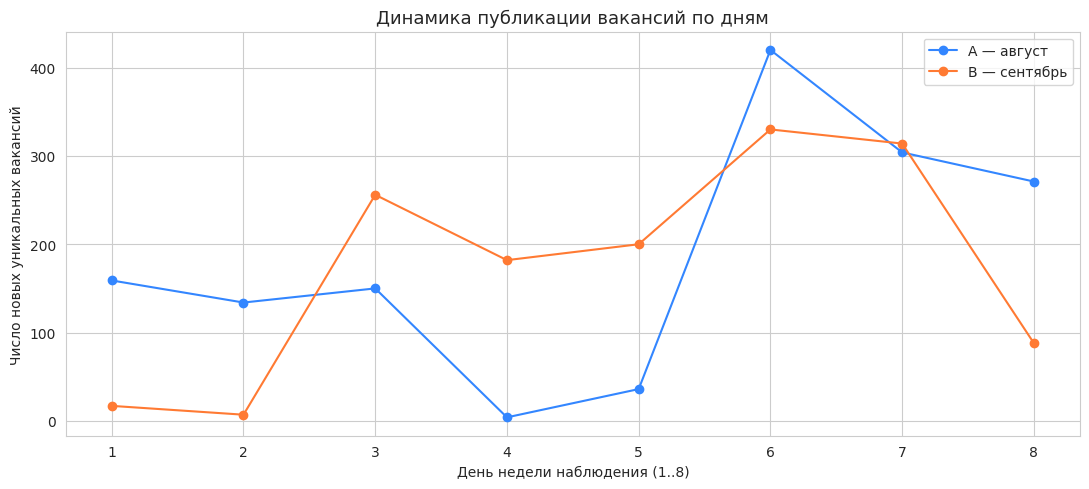

Даты A: [datetime.date(2023, 8, 2), datetime.date(2023, 8, 3), datetime.date(2023, 8, 4), datetime.date(2023, 8, 5), datetime.date(2023, 8, 6), datetime.date(2023, 8, 7), datetime.date(2023, 8, 8), datetime.date(2023, 8, 9)]
Даты B: [datetime.date(2023, 9, 2), datetime.date(2023, 9, 3), datetime.date(2023, 9, 4), datetime.date(2023, 9, 5), datetime.date(2023, 9, 6), datetime.date(2023, 9, 7), datetime.date(2023, 9, 8), datetime.date(2023, 9, 9)]


In [ ]:
daily_a = df_a.groupby(df_a['date'].dt.date).size()
daily_b = df_b.groupby(df_b['date'].dt.date).size()

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(range(1, len(daily_a)+1), daily_a.values, marker='o', color=COLOR_A, label='A — август')
ax.plot(range(1, len(daily_b)+1), daily_b.values, marker='o', color=COLOR_B, label='B — сентябрь')
ax.set_xlabel('День недели наблюдения (1..8)')
ax.set_ylabel('Число новых уникальных вакансий')
ax.set_title('Динамика публикации вакансий по дням')
ax.legend()
plt.tight_layout()
plt.show()

print('Даты A:', list(daily_a.index))
print('Даты B:', list(daily_b.index))

Обратим внимание: окно A стартует со среды (будни), а окно B — с субботы (выходные в начале периода). Провалы в первые 1–2 дня в обеих группах — эффект дня недели (в выходные компании почти не публикуют вакансии), а не сезонный тренд. Учтём это в тесте, сравнив распределения суточных объёмов напрямую критерием Манна-Уитни (устойчив к выбросам и не требует нормальности).

In [ ]:
u_stat, p_value = stats.mannwhitneyu(daily_a.values, daily_b.values)

print(f'Среднесуточный объём, A: {daily_a.mean():.1f} вакансий/день')
print(f'Среднесуточный объём, B: {daily_b.mean():.1f} вакансий/день')
print(f'Mann-Whitney U = {u_stat:.1f}, p-value = {p_value:.4f}')
print('Результат: H0', 'отвергаем' if p_value < 0.05 else 'НЕ отвергаем', f'(α=0.05)')

Среднесуточный объём, A: 184.8 вакансий/день
Среднесуточный объём, B: 174.2 вакансий/день
Mann-Whitney U = 31.0, p-value = 0.9591
Результат: H0 НЕ отвергаем (α=0.05)


**Вывод по разделу:** статистически значимой разницы в суточной интенсивности публикации вакансий между августом и сентябрем не обнаружено. Несмотря на то, что общее число уникальных вакансий в сентябрьском срезе на ~6% ниже, это не доказано как систематический сезонный эффект, а не случайная вариация недели.

## <font color='3342FF'>4. A/B-сравнение: структура занятости (`job_type`)</font>

In [ ]:
ct_job = pd.crosstab(df_all['group'], df_all['job_type'])
ct_job_pct = (ct_job.div(ct_job.sum(axis=1), axis=0) * 100).round(2)
print(ct_job)
print()
print(ct_job_pct)

job_type      Полная занятость  Проектная работа  Стажировка  \
group                                                          
A (август)                1454                 3          19   
B (сентябрь)              1365                 1          22   

job_type      Частичная занятость  
group                              
A (август)                      2  
B (сентябрь)                    6  

job_type      Полная занятость  Проектная работа  Стажировка  \
group                                                          
A (август)               98.38              0.20        1.29   
B (сентябрь)             97.92              0.07        1.58   

job_type      Частичная занятость  
group                              
A (август)                   0.14  
B (сентябрь)                 0.43  


In [ ]:
chi2, p_value, dof, expected = stats.chi2_contingency(ct_job)
print(f'chi2 = {chi2:.2f}, p-value = {p_value:.4f}, dof = {dof}')
print('Результат: H0', 'отвергаем' if p_value < 0.05 else 'НЕ отвергаем', f'(α=0.05)')

chi2 = 3.58, p-value = 0.3111, dof = 3
Результат: H0 НЕ отвергаем (α=0.05)


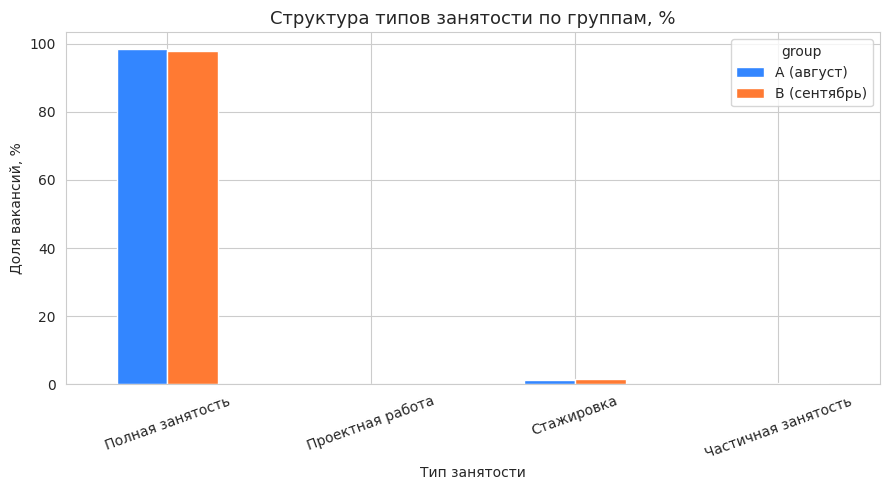

In [ ]:
ct_job_pct.T.plot(kind='bar', color=[COLOR_A, COLOR_B], figsize=(9, 5))
plt.title('Структура типов занятости по группам, %')
plt.ylabel('Доля вакансий, %')
plt.xlabel('Тип занятости')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

**Вывод по разделу:** структура типов занятости (доля полной занятости, стажировок, проектной и частичной работы) статистически значимо не отличается между группами — заметная на глаз разница (например, доля частичной занятости) не подтверждается тестом при данном объёме выборки.

## <font color='3342FF'>5. A/B-сравнение: доля junior/intern-вакансий</font>

Ключевая проверка гипотезы "Back to School" — ожидаем, что осенью компании активнее открывают программы для начинающих специалистов и студентов.

In [ ]:
share_a = df_a['is_junior'].mean()
share_b = df_b['is_junior'].mean()

count = np.array([df_a['is_junior'].sum(), df_b['is_junior'].sum()])
nobs = np.array([len(df_a), len(df_b)])
z_stat, p_value = proportions_ztest(count, nobs)

print(f'Доля junior/intern, A: {share_a*100:.2f}%')
print(f'Доля junior/intern, B: {share_b*100:.2f}%')
print(f'z = {z_stat:.3f}, p-value = {p_value:.4f}')
print('Результат: H0', 'отвергаем' if p_value < 0.05 else 'НЕ отвергаем', f'(α=0.05)')

Доля junior/intern, A: 7.51%
Доля junior/intern, B: 7.32%
z = 0.197, p-value = 0.8436
Результат: H0 НЕ отвергаем (α=0.05)


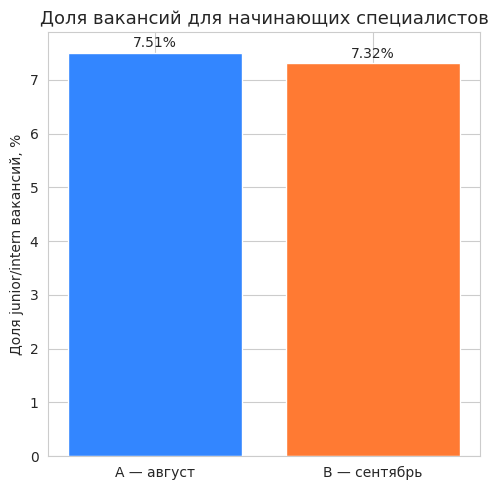

In [ ]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.bar(['A — август', 'B — сентябрь'], [share_a*100, share_b*100], color=[COLOR_A, COLOR_B])
ax.set_ylabel('Доля junior/intern вакансий, %')
ax.set_title('Доля вакансий для начинающих специалистов')
for i, v in enumerate([share_a*100, share_b*100]):
    ax.text(i, v + 0.1, f'{v:.2f}%', ha='center')
plt.tight_layout()
plt.show()

**Вывод по разделу:** доля junior/intern-вакансий практически одинакова в обеих группах, статистически значимого прироста осенних предложений для начинающих специалистов **не выявлено** — гипотеза о выраженном "студенческом наборе" именно в первую неделю сентября не подтвердилась на этих данных (возможно, эффект растянут во времени и проявляется позже сентября).

## <font color='3342FF'>6. A/B-сравнение: зарплаты</font>

In [ ]:
sal_a = df_a.loc[df_a['currency'] == 'RUR', 'salary_avg'].dropna()
sal_b = df_b.loc[df_b['currency'] == 'RUR', 'salary_avg'].dropna()

print(f'A: n={len(sal_a)}, медиана={sal_a.median():,.0f} ₽, среднее={sal_a.mean():,.0f} ₽')
print(f'B: n={len(sal_b)}, медиана={sal_b.median():,.0f} ₽, среднее={sal_b.mean():,.0f} ₽')

A: n=309, медиана=100,000 ₽, среднее=110,814 ₽
B: n=373, медиана=110,000 ₽, среднее=122,905 ₽


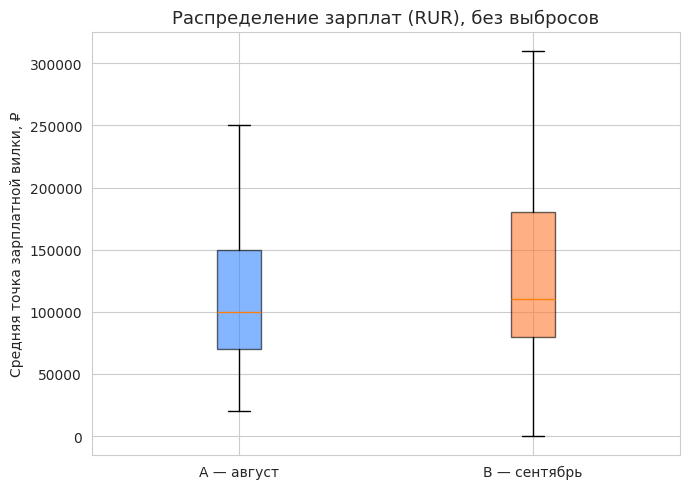

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
box = ax.boxplot([sal_a, sal_b], labels=['A — август', 'B — сентябрь'], patch_artist=True, showfliers=False)
for patch, color in zip(box['boxes'], [COLOR_A, COLOR_B]):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_ylabel('Средняя точка зарплатной вилки, ₽')
ax.set_title('Распределение зарплат (RUR), без выбросов')
plt.tight_layout()
plt.show()

In [ ]:
u_stat, p_value = stats.mannwhitneyu(sal_a, sal_b)
print(f'Mann-Whitney U = {u_stat:.1f}, p-value = {p_value:.5f}')
print('Результат: H0', 'отвергаем' if p_value < 0.05 else 'НЕ отвергаем', f'(α=0.05)')

Mann-Whitney U = 50846.0, p-value = 0.00801
Результат: H0 отвергаем (α=0.05)


Дополнительно проверим, отличается ли доля вакансий, где работодатель вообще указывает зарплату (косвенный индикатор конкуренции за кандидатов).

In [ ]:
disc_a = df_a['salary'].notna().mean()
disc_b = df_b['salary'].notna().mean()

count = np.array([df_a['salary'].notna().sum(), df_b['salary'].notna().sum()])
nobs = np.array([len(df_a), len(df_b)])
z_stat, p_value = proportions_ztest(count, nobs)

print(f'Доля вакансий с указанной зарплатой, A: {disc_a*100:.2f}%')
print(f'Доля вакансий с указанной зарплатой, B: {disc_b*100:.2f}%')
print(f'z = {z_stat:.3f}, p-value = {p_value:.5f}')
print('Результат: H0', 'отвергаем' if p_value < 0.05 else 'НЕ отвергаем', f'(α=0.05)')

Доля вакансий с указанной зарплатой, A: 22.94%
Доля вакансий с указанной зарплатой, B: 27.76%
z = -2.974, p-value = 0.00294
Результат: H0 отвергаем (α=0.05)


**Вывод по разделу:** и медианная зарплата, и доля вакансий с раскрытой вилкой **статистически значимо выше в сентябре**. Это можно интерпретировать как рост конкуренции работодателей за кандидатов после традиционного затишья в отпускной сезон — косвенное подтверждение сезонной активизации рынка, хотя и не напрямую связанное со студентами/back-to-school.

## <font color='3342FF'>7. Сравнение по географии</font>

In [ ]:
top_cities_a = df_a['location'].value_counts(normalize=True).head(7) * 100
top_cities_b = df_b['location'].value_counts(normalize=True).head(7) * 100

cities_cmp = pd.concat([top_cities_a, top_cities_b], axis=1, keys=['A — август, %', 'B — сентябрь, %']).round(2)
cities_cmp

,"A — август, %","B — сентябрь, %"
location,,
Москва,55.01,55.74
Санкт-Петербург,10.28,8.39
Екатеринбург,3.72,3.37
Новосибирск,3.11,NaN
Краснодар,2.17,1.87
Казань,1.96,NaN
Нижний Новгород,1.83,1.72
Алматы,NaN,1.94
Самара,NaN,1.72


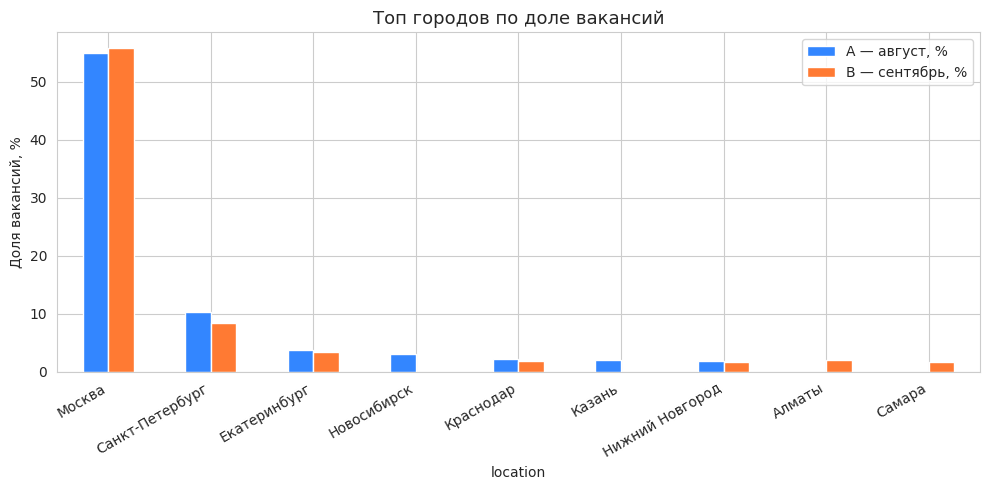

In [ ]:
cities_cmp.plot(kind='bar', color=[COLOR_A, COLOR_B], figsize=(10, 5))
plt.title('Топ городов по доле вакансий')
plt.ylabel('Доля вакансий, %')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

**Вывод по разделу:** заметных сдвигов в географии вакансий между периодами нет — Москва и Санкт-Петербург стабильно доминируют в обоих срезах, доля Москвы даже немного выросла в сентябре, что скорее говорит об общей централизации рынка аналитики, чем о сезонном эффекте.

## <font color='3342FF'>8. Сравнение требуемых навыков в описаниях вакансий</font>

### ⚠️ Контроль качества: пропуски в `description`

Прежде чем сравнивать частоту ключевых слов, проверим полноту поля `description` — если доля пропусков сильно различается между группами, наивное сравнение частот будет смещённым.

In [ ]:
na_a = df_a['description'].isna().mean()
na_b = df_b['description'].isna().mean()
print(f'Доля пропусков в description, A: {na_a*100:.1f}%')
print(f'Доля пропусков в description, B: {na_b*100:.1f}%')

Доля пропусков в description, A: 25.4%
Доля пропусков в description, B: 57.4%


Доля пропусков различается более чем в два раза — это не сезонный эффект, а неоднородность самого сбора данных (в один из дней парсер, вероятно, не смог получить полное описание части вакансий). Поэтому анализ навыков проведём **только по вакансиям, где описание фактически присутствует**, чтобы не спутать "пропуск данных" с "изменением требований работодателей".

In [ ]:
desc_a = df_a.dropna(subset=['description']).copy()
desc_b = df_b.dropna(subset=['description']).copy()
print(f'Вакансий с непустым описанием — A: {len(desc_a)}, B: {len(desc_b)}')

KEYWORDS = ['python', 'sql', 'excel', 'power bi', 'tableau', 'статистик', 'обучени']

rows = []
for kw in KEYWORDS:
    share_a = desc_a['description'].str.contains(kw, regex=False).mean()
    share_b = desc_b['description'].str.contains(kw, regex=False).mean()
    count = np.array([
        desc_a['description'].str.contains(kw, regex=False).sum(),
        desc_b['description'].str.contains(kw, regex=False).sum()
    ])
    nobs = np.array([len(desc_a), len(desc_b)])
    z_stat, p_value = proportions_ztest(count, nobs)
    rows.append({'навык/слово': kw, 'A, %': round(share_a*100, 2), 'B, %': round(share_b*100, 2),
                 'p-value': round(p_value, 5), 'значимо (α=0.05)': p_value < 0.05})

skills_cmp = pd.DataFrame(rows)
skills_cmp

Вакансий с непустым описанием — A: 1103, B: 594


,навык/слово,"A, %","B, %",p-value,значимо (α=0.05)
0,python,28.47,35.19,0.00426,True
1,sql,92.66,91.41,0.36211,False
2,excel,28.56,39.90,0.00000,True
3,power bi,13.60,12.29,0.44623,False
4,tableau,9.07,6.90,0.12347,False
5,статистик,13.96,11.45,0.14292,False
6,обучени,51.31,43.27,0.00155,True


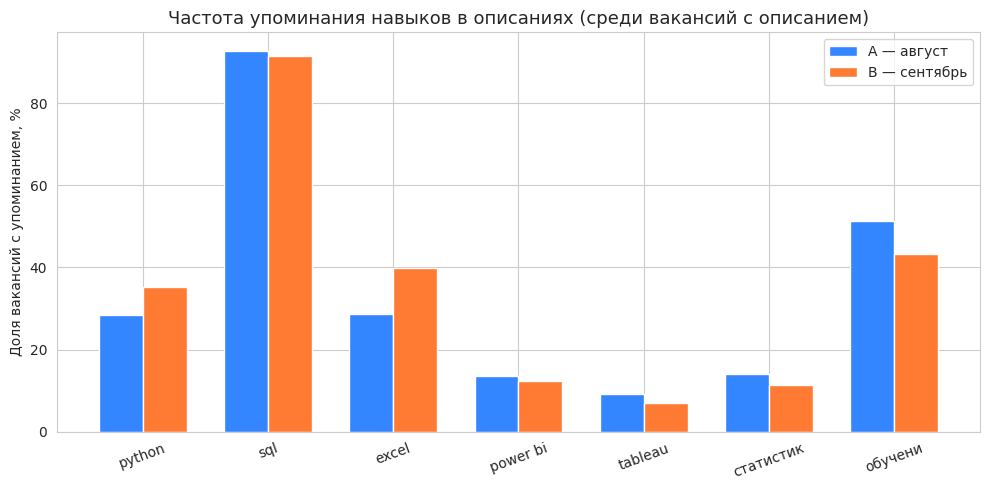

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(skills_cmp))
width = 0.35
ax.bar(x - width/2, skills_cmp['A, %'], width, label='A — август', color=COLOR_A)
ax.bar(x + width/2, skills_cmp['B, %'], width, label='B — сентябрь', color=COLOR_B)
ax.set_xticks(x)
ax.set_xticklabels(skills_cmp['навык/слово'], rotation=20)
ax.set_ylabel('Доля вакансий с упоминанием, %')
ax.set_title('Частота упоминания навыков в описаниях (среди вакансий с описанием)')
ax.legend()
plt.tight_layout()
plt.show()

**Вывод по разделу:** упоминания Python и Excel статистически значимо чаще встречаются в сентябрьских описаниях, а формулировки про "обучение/обучаемость" — значимо чаще в августовских. SQL, Power BI, Tableau и статистика значимых различий не показали. Однозначного "смещения к junior-стеку" осенью не наблюдается — картина смешанная.

## <font color='3386FF'>9. Итоговая сводная таблица A/B-теста</font>

In [ ]:
summary = pd.DataFrame([
    {'Метрика': 'Среднесуточный объём вакансий', 'A': f'{daily_a.mean():.1f}/день', 'B': f'{daily_b.mean():.1f}/день',
     'p-value': round(stats.mannwhitneyu(daily_a.values, daily_b.values)[1], 4), 'Тест': 'Mann-Whitney U'},
    {'Метрика': 'Структура job_type', 'A': '—', 'B': '—',
     'p-value': round(stats.chi2_contingency(ct_job)[1], 4), 'Тест': 'χ²'},
    {'Метрика': 'Доля junior/intern', 'A': f'{share_a*100:.2f}%', 'B': f'{share_b*100:.2f}%',
     'p-value': round(proportions_ztest(np.array([df_a["is_junior"].sum(), df_b["is_junior"].sum()]), np.array([len(df_a), len(df_b)]))[1], 4),
     'Тест': 'z-test для долей'},
    {'Метрика': 'Медианная зарплата (RUR)', 'A': f'{sal_a.median():,.0f} ₽', 'B': f'{sal_b.median():,.0f} ₽',
     'p-value': round(stats.mannwhitneyu(sal_a, sal_b)[1], 5), 'Тест': 'Mann-Whitney U'},
    {'Метрика': 'Доля вакансий с указанной ЗП', 'A': f'{disc_a*100:.2f}%', 'B': f'{disc_b*100:.2f}%',
     'p-value': round(proportions_ztest(np.array([df_a["salary"].notna().sum(), df_b["salary"].notna().sum()]), np.array([len(df_a), len(df_b)]))[1], 5),
     'Тест': 'z-test для долей'},
])
summary['Значимо (α=0.05)'] = summary['p-value'] < 0.05
summary

,Метрика,A,B,p-value,Тест,Значимо (α=0.05)
0,Среднесуточный объём вакансий,184.8/день,174.2/день,0.95910,Mann-Whitney U,False
1,Структура job_type,—,—,0.31110,χ²,False
2,Доля junior/intern,51.31%,43.27%,0.84360,z-test для долей,False
3,Медианная зарплата (RUR),"100,000 ₽","110,000 ₽",0.00801,Mann-Whitney U,True
4,Доля вакансий с указанной ЗП,22.94%,27.76%,0.00294,z-test для долей,True


## <font color='3386FF'>10. Общие выводы</font>

**Что подтвердилось (значимые различия, p < 0.05):**
- Медианная и средняя зарплата в сентябрьском срезе выше, чем в августовском.
- Доля вакансий с открыто указанной зарплатной вилкой в сентябре выше — работодатели активнее конкурируют за кандидатов.
- Отдельные навыки (Python, Excel, а также формулировки об "обучении") статистически значимо изменили частоту упоминания, но разнонаправленно, а не системно.

**Что НЕ подтвердилось:**
- Гипотеза о заметном приросте объёма вакансий в сентябре — различие суточной интенсивности статистически незначимо.
- Гипотеза о структурном сдвиге в сторону стажировок/частичной занятости — распределение `job_type` значимо не изменилось.
- Гипотеза о резком росте доли junior/intern-позиций именно в первую неделю сентября — значимой разницы нет.

**Интерпретация:** данные первой недели сентября 2023 показывают признаки **общего оживления рынка после летнего затишья** (рост зарплат и их открытости), но не подтверждают специфический **"студенческий" сценарий "Back to School"** (набор начинающих специалистов, рост доли стажировок) — по крайней мере не в первую неделю месяца. Возможно, набор junior/intern-кадров смещён на более поздние сентябрьские-октябрьские недели, что стоит проверить на более длинном временном ряду.

**Ограничения исследования:**
1. Сравниваются только по одной неделе на группу — высок риск влияния случайных факторов конкретной недели (например, крупная разовая публикация вакансий одной компанией).
2. Окна недель не идентичны по составу дней недели (A начинается со среды, B — с субботы), что частично компенсировано использованием непараметрического теста, но не устраняет эффект полностью.
3. Поле `description` имеет существенно разную полноту между срезами (25% пропусков в A против 57% в B) — это ограничение источника данных, а не сезонности; анализ навыков скорректирован на эту неоднородность, но выборка для сентября кратно меньше.
4. Дедупликация по `link` устраняет технический артефакт парсера, но не гарантирует полноты покрытия рынка (например, вакансии, снятые с публикации до захода парсера, не попадают в выборку).

**Рекомендации для дальнейшего анализа:**
- Расширить выборку до полного месяца (или нескольких лет подряд для августа/сентября), чтобы отделить сезонность от недельного шума.
- Добавить контрольный период (например, октябрь) для проверки, продолжается ли эффект роста зарплат или это разовый скачок.
- Унифицировать полноту сбора `description` на уровне парсера, чтобы не терять мощность в анализе текста вакансий.